<a href="https://colab.research.google.com/github/quangenai-stack/hocsau/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Load EDA

1.1
Load data & kiểm tra tổng quan

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
df = pd.read_csv("https://raw.githubusercontent.com/quangenai-stack/hocsau/refs/heads/main/StudentPerformanceFactors.csv")

In [20]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/quangenai-stack/hocsau/refs/heads/main/StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


1.2 Kiểm tra missing values

In [15]:
#Kiểm tra
missing = df.isnull().sum()
print("Missing values:\n", missing[missing > 0])
print("\n% missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values:
 Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

% missing:
Hours_Studied                 0.00
Attendance                    0.00
Parental_Involvement          0.00
Access_to_Resources           0.00
Extracurricular_Activities    0.00
Sleep_Hours                   0.00
Previous_Scores               0.00
Motivation_Level              0.00
Internet_Access               0.00
Tutoring_Sessions             0.00
Family_Income                 0.00
Teacher_Quality               1.18
School_Type                   0.00
Peer_Influence                0.00
Physical_Activity             0.00
Learning_Disabilities         0.00
Parental_Education_Level      1.36
Distance_from_Home            1.01
Gender                        0.00
Exam_Score                    0.00
dtype: float64


1.3 EDA — phân phối và tương quan

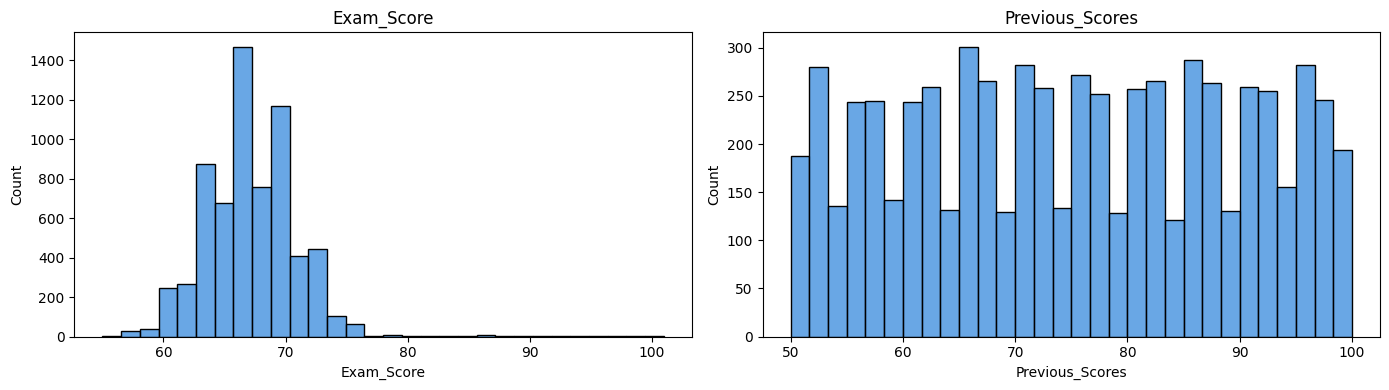

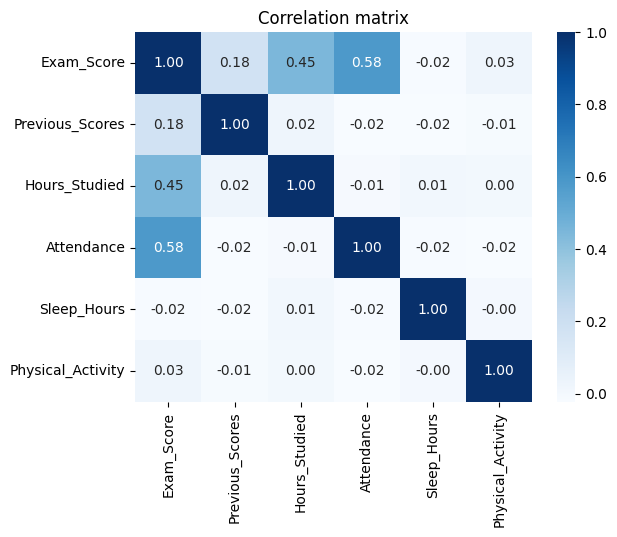

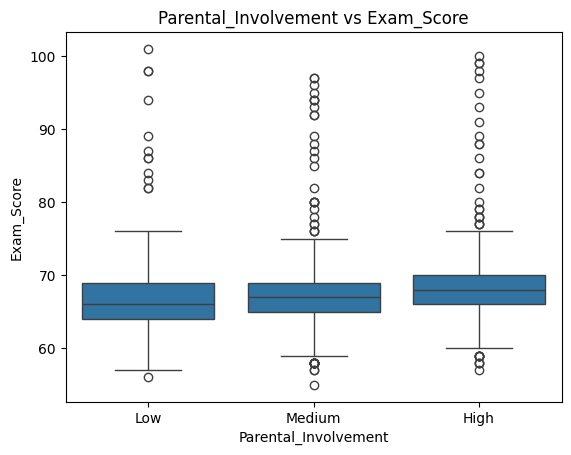

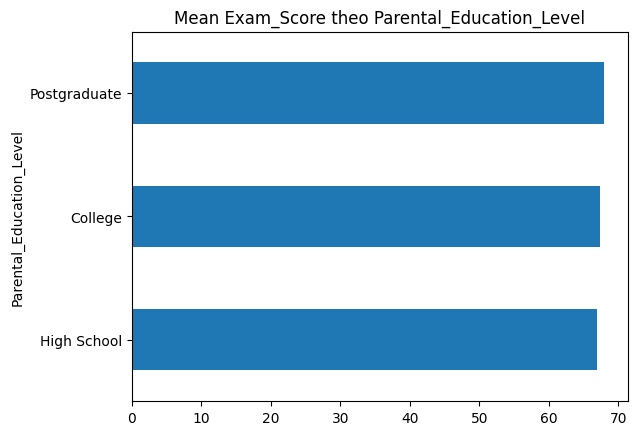

In [21]:
# EDA — phân phối và tương quan

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['Exam_Score', 'Previous_Scores']):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color='#378ADD')
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Using relevant numerical columns for correlation matrix
num_cols = ['Exam_Score', 'Previous_Scores', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Physical_Activity']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation matrix')
plt.show()

# Using 'Parental_Involvement' as a categorical variable against 'Exam_Score'
sns.boxplot(data=df, x='Parental_Involvement', y='Exam_Score')
plt.title('Parental_Involvement vs Exam_Score')
plt.show()

# Using 'Parental_Education_Level' against 'Exam_Score'
df.groupby('Parental_Education_Level')['Exam_Score'].mean().sort_values().plot(kind='barh')
plt.title('Mean Exam_Score theo Parental_Education_Level')
plt.show()

2. Tiền xử lý

2.1 Xử lý missing values

In [23]:
# Xử lý missing values

cat_fill = {
    'Teacher_Quality': 'unknown',
    'Parental_Education_Level': 'unknown',
    'Distance_from_Home': 'unknown'
}
df.fillna(cat_fill, inplace=True)
print("Missing sau xử lý:", df.isnull().sum().sum())

Missing sau xử lý: 0


2.2 Encode categorical → số

In [26]:


df['Gender_enc']        = (df['Gender'] == 'Male').astype(int)

# Binary columns encoding
df['Extracurricular_Activities_enc'] = (df['Extracurricular_Activities'] == 'Yes').astype(int)
df['Internet_Access_enc'] = (df['Internet_Access'] == 'Yes').astype(int)
df['Learning_Disabilities_enc'] = (df['Learning_Disabilities'] == 'Yes').astype(int)
df['School_Type_enc'] = (df['School_Type'] == 'Public').astype(int)

# Ordinal columns encoding using map
parental_involvement_order = {'Low': 0, 'Medium': 1, 'High': 2}
access_to_resources_order = {'Low': 0, 'Medium': 1, 'High': 2}
motivation_level_order = {'Low': 0, 'Medium': 1, 'High': 2}
family_income_order = {'Low': 0, 'Medium': 1, 'High': 2}
teacher_quality_order = {'Low': 0, 'Medium': 1, 'High': 2, 'unknown': 0} # 'unknown' handled in previous step
peer_influence_order = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
parental_education_order = {'High School': 1, 'College': 2, 'Postgraduate': 3, 'unknown': 0} # 'unknown' handled in previous step
distance_from_home_order = {'Near': 1, 'Moderate': 2, 'Far': 3, 'unknown': 0} # 'unknown' handled in previous step

df['Parental_Involvement_enc'] = df['Parental_Involvement'].map(parental_involvement_order)
df['Access_to_Resources_enc'] = df['Access_to_Resources'].map(access_to_resources_order)
df['Motivation_Level_enc'] = df['Motivation_Level'].map(motivation_level_order)
df['Family_Income_enc'] = df['Family_Income'].map(family_income_order)
df['Teacher_Quality_enc'] = df['Teacher_Quality'].map(teacher_quality_order)
df['Peer_Influence_enc'] = df['Peer_Influence'].map(peer_influence_order)
df['Parental_Education_Level_enc'] = df['Parental_Education_Level'].map(parental_education_order)
df['Distance_from_Home_enc'] = df['Distance_from_Home'].map(distance_from_home_order)

# No appropriate columns for pd.get_dummies from the current dataset based on head() for now.

2.3 Chọn features & scale

In [28]:


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

feature_cols = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Physical_Activity',
    'Gender_enc',
    'Extracurricular_Activities_enc',
    'Internet_Access_enc',
    'Learning_Disabilities_enc',
    'School_Type_enc',
    'Parental_Involvement_enc',
    'Access_to_Resources_enc',
    'Motivation_Level_enc',
    'Family_Income_enc',
    'Teacher_Quality_enc',
    'Peer_Influence_enc',
    'Parental_Education_Level_enc',
    'Distance_from_Home_enc'
]

X = df[feature_cols]
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

3. Train

3.1 Train Linear Regression

In [29]:
# Train Linear Regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_sc, y_train)

coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': model.coef_}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.3f}")

                       Feature  Coefficient
                    Attendance     2.293142
                 Hours_Studied     1.756055
       Access_to_Resources_enc     0.733560
               Previous_Scores     0.708144
      Parental_Involvement_enc     0.698875
             Tutoring_Sessions     0.626586
             Family_Income_enc     0.400543
            Peer_Influence_enc     0.397045
  Parental_Education_Level_enc     0.369572
          Motivation_Level_enc     0.359312
           Teacher_Quality_enc     0.310047
Extracurricular_Activities_enc     0.282462
           Internet_Access_enc     0.256334
             Physical_Activity     0.197217
               School_Type_enc     0.010107
                    Gender_enc    -0.012543
                   Sleep_Hours    -0.019271
     Learning_Disabilities_enc    -0.266356
        Distance_from_Home_enc    -0.300036

Intercept: 67.215


3.2 Visualize feature importance

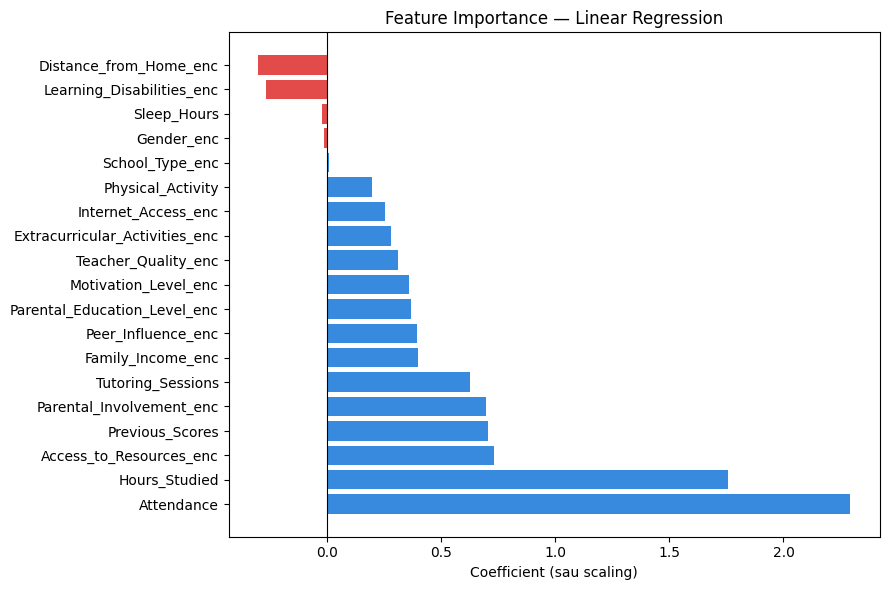

In [30]:
plt.figure(figsize=(9, 6))
colors = ['#378ADD' if v >= 0 else '#E24B4A' for v in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (sau scaling)')
plt.title('Feature Importance — Linear Regression')
plt.tight_layout(); plt.show()

4. Đánh giá

4.1 Tính metrics đánh giá

In [31]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred = model.predict(X_test_sc)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.2f} điểm")
print(f"MAE  : {mae:.2f} điểm")
print(f"R²   : {r2:.4f}  ({r2*100:.1f}% variance)")

r2_train = r2_score(y_train, model.predict(X_train_sc))
print(f"\nR² Train : {r2_train:.4f}")
print(f"R² Test  : {r2:.4f}")

RMSE : 1.81 điểm
MAE  : 0.46 điểm
R²   : 0.7693  (76.9% variance)

R² Train : 0.7161
R² Test  : 0.7693


4.2 Vẽ biểu đồ đánh giá

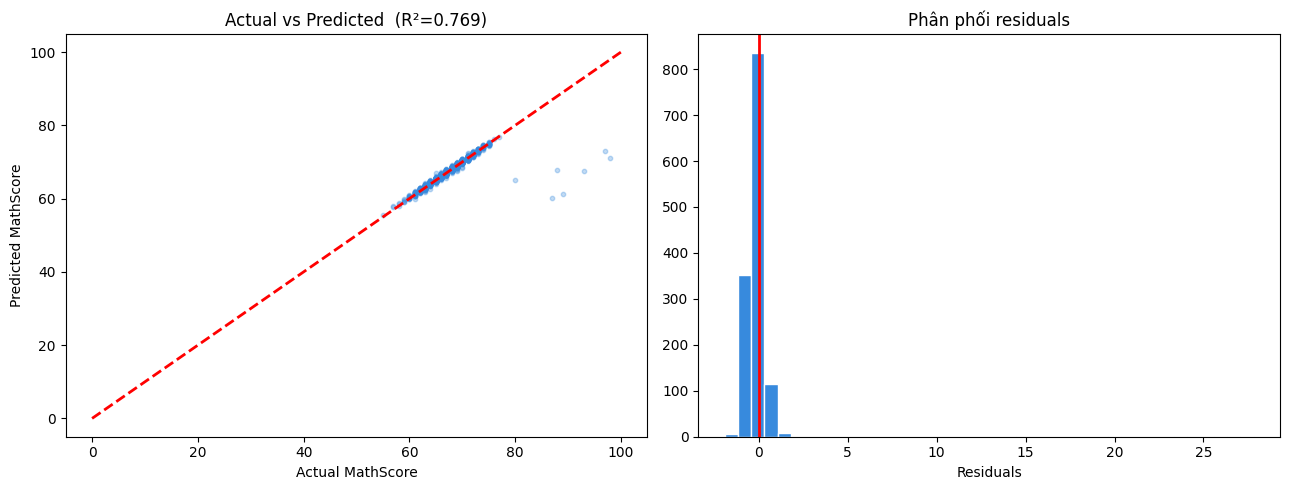

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='#378ADD')
axes[0].plot([0,100], [0,100], 'r--', lw=2)
axes[0].set_xlabel('Actual MathScore')
axes[0].set_ylabel('Predicted MathScore')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')

residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='#378ADD', edgecolor='white')
axes[1].axvline(0, color='red', lw=2)
axes[1].set_xlabel('Residuals')
axes[1].set_title('Phân phối residuals')
plt.tight_layout(); plt.show()